In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report, accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image as kimage


In [3]:
# ---------------------------
# 0. (Optional) Mount Google Drive in Colab
# ---------------------------
from google.colab import drive
drive.mount('/content/drive')
BASE = "/content/drive/MyDrive/Federated_Cancer_Project"  # change if different



Mounted at /content/drive


In [4]:
CLINICAL_CSV = os.path.join(BASE, "clinical.csv")
GENOMIC_CSV  = os.path.join(BASE, "genomic.csv")
IMG_DIR      = os.path.join("/content/drive/MyDrive/Federated_Cancer_Project/image/", "images_mri")



In [5]:
clin_df = pd.read_csv(CLINICAL_CSV)
gen_df  = pd.read_csv(GENOMIC_CSV)
print("Clinical columns:", clin_df.columns.tolist())
print("Genomic columns (example):", gen_df.columns[:10].tolist(), "...", gen_df.columns[-3:].tolist())



Clinical columns: ['age', 'tumor_stage', 'treatment_type', 'lymph_nodes', 'tumor_size_cm', 'relapse']
Genomic columns (example): ['gene_1', 'gene_2', 'gene_3', 'gene_4', 'gene_5', 'gene_6', 'gene_7', 'gene_8', 'gene_9', 'gene_10'] ... ['gene_499', 'gene_500', 'relapse']


In [6]:
if 'relapse' not in clin_df.columns and 'relapse' not in gen_df.columns:
    raise ValueError("No 'relapse' column found in either CSV. One CSV must contain the target column 'relapse' (0/1).")

# Prefer clinical relapse if present, else genomic
if 'relapse' in clin_df.columns:
    target_series = clin_df['relapse'].astype(int)
elif 'relapse' in gen_df.columns:
    target_series = gen_df['relapse'].astype(int)



In [7]:
# 4. Merge CSVs by index (no patient_id provided)
# ---------------------------
# WARNING: merging by index assumes rows are aligned between the two files.
merged = pd.concat([gen_df.reset_index(drop=True), clin_df.reset_index(drop=True)], axis=1)
# If relapse present in both, keep 'relapse' from clinical (we already set target_series)
merged['relapse_final'] = target_series.reset_index(drop=True)
merged = merged.dropna(subset=['relapse_final']).reset_index(drop=True)
print("Merged dataframe shape:", merged.shape)



Merged dataframe shape: (2000, 508)


In [8]:
# 5. Split feature columns: genomic vs clinical
# ---------------------------
# From your description:
# clinical.csv: age, tumor_stage, treatment_type, lymph_nodes, tumor_size_cm, relapse
# genomic.csv: gene_1 ... gene_500, relapse

# We'll pick features based on column name patterns.
clin_feature_candidates = ['age','tumor_stage','treatment_type','lymph_nodes','tumor_size_cm']
gen_feature_candidates = [c for c in merged.columns if c.startswith('gene_')]

clin_cols = [c for c in clin_feature_candidates if c in merged.columns]
gen_cols  = gen_feature_candidates

print(f"Detected {len(clin_cols)} clinical features, {len(gen_cols)} genomic features.")

# Extract X and y
X_clin_df = merged[clin_cols].copy()        # may contain categorical 'treatment_type' and 'tumor_stage'
X_gen_df  = merged[gen_cols].copy()         # numeric gene expression columns
y         = merged['relapse_final'].astype(int).values




Detected 5 clinical features, 500 genomic features.


In [9]:
# 6. Preprocess clinical & genomic features
# ---------------------------
def preprocess_features(df):
    """One-hot encode categoricals and scale numerics. Returns (array, transformer)"""
    if df.shape[1] == 0:
        return np.zeros((len(df), 0)), None
    cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    transformers = []
    if num_cols:
        transformers.append(('num', StandardScaler(), num_cols))
    if cat_cols:
        # Updated 'sparse=False' to 'sparse_output=False' for newer scikit-learn versions
        transformers.append(('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_cols))
    pre = ColumnTransformer(transformers=transformers)
    arr = pre.fit_transform(df)
    return arr, pre

X_clin, clin_pre = preprocess_features(X_clin_df)
X_gen, gen_pre   = preprocess_features(X_gen_df)

print("Processed clinical shape:", X_clin.shape)
print("Processed genomic shape:", X_gen.shape)


Processed clinical shape: (2000, 11)
Processed genomic shape: (2000, 500)


In [10]:
# 7. Prepare images mapped by index to filenames like 001.jpg
# ---------------------------
# Assumption: for row i (0-based), expected filename is zero-padded (n_digits) form of (i+1)
n_samples = merged.shape[0]
# determine padding length from number of digits in n_samples (min 3 as user example shows 001.jpg)
pad = max(3, len(str(n_samples)))

# helper to find image path for a sample index across both subfolders
def find_image_for_index(idx, img_base_dir, pad_digits=3):
    pid = str(idx+1).zfill(pad_digits)  # 1-based index, zero-padded
    # look for file named pid.* in both subfolders
    for cls_sub in ['relapse','no_relapse']:
        folder = os.path.join(img_base_dir, cls_sub)
        if not os.path.isdir(folder):
            continue
        for ext in ['.jpg','.jpeg','.png','.bmp','.tiff']:
            candidate = os.path.join(folder, pid + ext)
            if os.path.exists(candidate):
                return candidate
    # if exact match not found, try contains pid
    for root, _, files in os.walk(img_base_dir):
        for f in files:
            name = os.path.splitext(f)[0]
            if pid in name:
                return os.path.join(root, f)
    return None

# Build image list (same order as merged rows)
image_paths = []
missing = 0
for i in range(n_samples):
    p = find_image_for_index(i, IMG_DIR, pad_digits=pad)
    if p is None:
        missing += 1
    image_paths.append(p)
print(f"Found images for {n_samples - missing} / {n_samples} samples. Missing: {missing}")

# Load images into memory (OK for small/medium datasets). For large datasets, switch to tf.data pipeline.
IMG_H, IMG_W = 224, 224
def load_img_or_blank(path):
    if path is None or not os.path.exists(path):
        return np.zeros((IMG_H, IMG_W, 3), dtype=np.float32)
    img = kimage.load_img(path, target_size=(IMG_H, IMG_W))
    arr = kimage.img_to_array(img).astype(np.float32) / 255.0
    return arr

X_img = np.stack([load_img_or_blank(p) for p in image_paths], axis=0)
print("Image array shape:", X_img.shape)



Found images for 500 / 2000 samples. Missing: 1500
Image array shape: (2000, 224, 224, 3)


In [11]:
# 8. Train-test split (stratify by y)
# ---------------------------
Xg_train, Xg_test, Xc_train, Xc_test, Xi_train, Xi_test, y_train, y_test = train_test_split(
    X_gen, X_clin, X_img, y, test_size=0.2, random_state=42, stratify=y
)
print("Train / Test sizes:", Xg_train.shape[0], Xg_test.shape[0])



Train / Test sizes: 1600 400


In [12]:
# 9. Build per-modality feature extractors
# ---------------------------
# Genomic MLP
def build_genomic_extractor(input_dim, feat_dim=64):
    inp = keras.Input(shape=(input_dim,), name="genomic_input")
    x = layers.Dense(256, activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(feat_dim, activation='relu', name='genomic_feat')(x)
    return Model(inp, x, name='genomic_extractor')

# Clinical MLP
def build_clinical_extractor(input_dim, feat_dim=32):
    if input_dim == 0:
        # if no clinical features, return zero-features
        inp = keras.Input(shape=(0,), name="clin_input")
        out = layers.Lambda(lambda z: tf.zeros((tf.shape(z)[0], feat_dim)))(inp)
        return Model(inp, out, name='clinical_empty')
    inp = keras.Input(shape=(input_dim,), name="clinical_input")
    x = layers.Dense(128, activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(feat_dim, activation='relu', name='clinical_feat')(x)
    return Model(inp, x, name='clinical_extractor')

# Image extractor (MobileNetV2)
base_img = keras.applications.MobileNetV2(input_shape=(IMG_H, IMG_W, 3), include_top=False, weights='imagenet', pooling='avg')
base_img.trainable = False  # freeze initial
img_in = keras.Input(shape=(IMG_H, IMG_W, 3), name='image_input')
img_feat = base_img(img_in)
img_feat = layers.Dense(128, activation='relu', name='img_feat')(img_feat)
img_extractor = Model(img_in, img_feat, name='image_extractor')

# instantiate extractors
gen_extractor = build_genomic_extractor(Xg_train.shape[1], feat_dim=64)
clin_extractor = build_clinical_extractor(Xc_train.shape[1], feat_dim=32)

gen_extractor.summary()
clin_extractor.summary()
img_extractor.summary()



9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "genomic_extractor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ genomic_input (InputLayer)      │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       128,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ genomic_feat (Dense)            │ (None, 64)             │        16,448 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 145,728 (569.25 KB)

 Trainable params: 145,216 (567.25 KB)

...

Model: "image_extractor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ img_feat (Dense)                │ (None, 128)            │       163,968 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,421,952 (9.24 MB)

 Trainable params: 163,968 (640.50 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [13]:
# 10. Build fusion model (concatenate features)
# ---------------------------
g_in = keras.Input(shape=(Xg_train.shape[1],), name='g_input')
c_in = keras.Input(shape=(Xc_train.shape[1],), name='c_input')
i_in = keras.Input(shape=(IMG_H, IMG_W, 3), name='i_input')

g_feat = gen_extractor(g_in)
c_feat = clin_extractor(c_in)
i_feat = img_extractor(i_in)

combined = layers.Concatenate(name='fusion_concat')([g_feat, c_feat, i_feat])
x = layers.Dense(128, activation='relu')(combined)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(64, activation='relu')(x)
out = layers.Dense(1, activation='sigmoid', name='relapse_output')(x)

fusion_model = Model(inputs=[g_in, c_in, i_in], outputs=out, name='fusion_model')
fusion_model.compile(optimizer=keras.optimizers.Adam(1e-4), loss='binary_crossentropy', metrics=['accuracy'])
fusion_model.summary()


Model: "fusion_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ g_input             │ (None, 500)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ c_input             │ (None, 11)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ i_input             │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ genomic_extractor   │ (None, 64)        │    145,728 │ g_input[0][0]     │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clinical_extractor  │ (None, 32)        │      6,176 │ c_input[0][0]     │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_extractor     │ (None, 128)       │  2,421,952 │ i_input[0][0]     │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_concat       │ (None, 224)       │          0 │ genomic_extracto… │
│ (Concatenate)       │                   │            │ clinical_extract… │
│                     │                   │            │ image_extractor[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     28,800 │ fusion_concat[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relapse_output      │ (None, 1)         │         65 │ dense_3[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,611,489 (9.96 MB)

 Trainable params: 352,481 (1.34 MB)

 Non-trainable params: 2,259,008 (8.62 MB)

In [14]:
# ---------------------------
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint('best_fusion.keras', monitor='val_loss', save_best_only=True)
]



In [15]:
# 12. Train fusion model
# ---------------------------
EPOCHS = 5
BATCH_SIZE = 16

history = fusion_model.fit(
    x=[Xg_train, Xc_train, Xi_train],
    y=y_train,
    validation_data=([Xg_test, Xc_test, Xi_test], y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks
)



Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 98s 793ms/step - accuracy: 0.5942 - loss: 0.7407 - val_accuracy: 0.5950 - val_loss: 0.6655
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 74s 739ms/step - accuracy: 0.6429 - loss: 0.6423 - val_accuracy: 0.6275 - val_loss: 0.6522
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 85s 849ms/step - accuracy: 0.6682 - loss: 0.6190 - val_accuracy: 0.6550 - val_loss: 0.6085
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 74s 738ms/step - accuracy: 0.6815 - loss: 0.5980 - val_accuracy: 0.7125 - val_loss: 0.5617
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 85s 764ms/step - accuracy: 0.7053 - loss: 0.5322 - val_accuracy: 0.7725 - val_loss: 0.4811


In [16]:
# 13. Save the model and extractors
# ---------------------------
out_dir = "/content/drive/MyDrive/Federated_Cancer_Project/models_fusion"
os.makedirs(out_dir, exist_ok=True)
fusion_model.save(os.path.join(out_dir, "fusion_model.keras"))
gen_extractor.save(os.path.join(out_dir, "genomic_extractor.keras"))
clin_extractor.save(os.path.join(out_dir, "clinical_extractor.keras"))
img_extractor.save(os.path.join(out_dir, "image_extractor.keras"))
print("Saved models to:", out_dir)



Saved models to: /content/drive/MyDrive/Federated_Cancer_Project/models_fusion


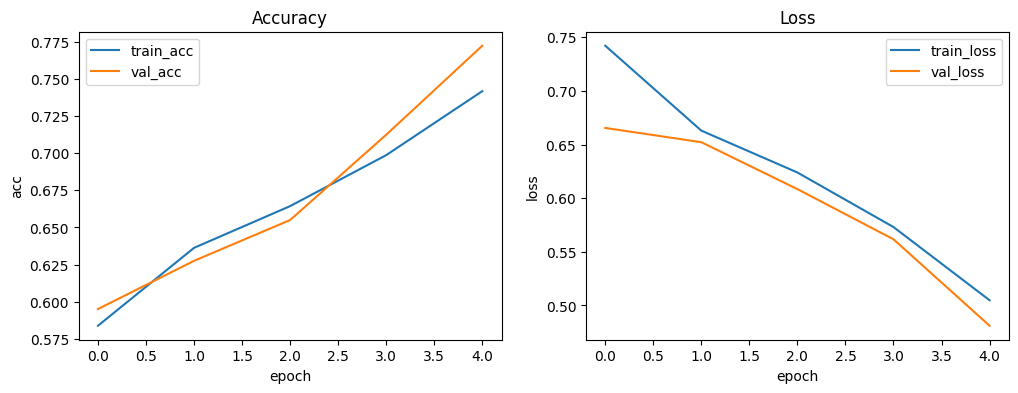

25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 592ms/step
Test accuracy: 0.7725
Classification report:
               precision    recall  f1-score   support

           0       0.78      0.89      0.83       257
           1       0.75      0.55      0.63       143

    accuracy                           0.77       400
   macro avg       0.76      0.72      0.73       400
weighted avg       0.77      0.77      0.76       400



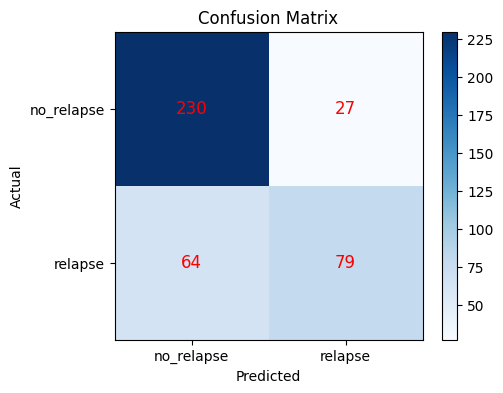

ROC AUC: 0.8334194987891486


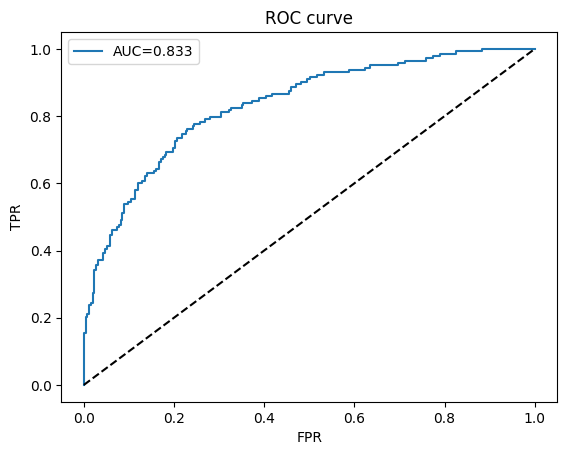

In [17]:
# 14. Evaluation & Plots
# ---------------------------
# Training curves
def plot_training(history):
    hist = history.history
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(hist['accuracy'], label='train_acc')
    plt.plot(hist['val_accuracy'], label='val_acc')
    plt.title('Accuracy')
    plt.xlabel('epoch'); plt.ylabel('acc'); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(hist['loss'], label='train_loss')
    plt.plot(hist['val_loss'], label='val_loss')
    plt.title('Loss')
    plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend()
    plt.show()

plot_training(history)

# Predictions
y_prob = fusion_model.predict([Xg_test, Xc_test, Xi_test], batch_size=BATCH_SIZE).flatten()
y_pred = (y_prob >= 0.5).astype(int)

# Accuracy, classification report
acc = accuracy_score(y_test, y_pred)
print("Test accuracy:", acc)
print("Classification report:\n", classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['no_relapse','relapse'])
plt.yticks(tick_marks, ['no_relapse','relapse'])
for i,j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i,j], ha='center', va='center', color='red', fontsize=12)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.show()

# ROC AUC
try:
    auc = roc_auc_score(y_test, y_prob)
    print("ROC AUC:", auc)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
    plt.plot([0,1],[0,1],'k--'); plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC curve'); plt.legend(); plt.show()
except Exception as e:
    print("ROC AUC error:", e)


In [18]:
# 15. Quick inference function for a single row
# ---------------------------
def predict_single_row(gen_row, clin_row, img_path=None):
    """Provide raw feature arrays (1D) for genomic and clinical (preprocessed) and image path (optional).
       Returns relapse probability and predicted label."""
    # preprocess single row using fitted transformers
    if gen_pre is not None:
        xg = gen_pre.transform(pd.DataFrame([gen_row]))  # returns 2D
    else:
        xg = np.zeros((1,0))
    if clin_pre is not None:
        xc = clin_pre.transform(pd.DataFrame([clin_row]))
    else:
        xc = np.zeros((1,0))
    if img_path is None:
        xi = np.zeros((1,IMG_H,IMG_W,3), dtype=np.float32)
    else:
        xi = np.expand_dims(load_img_or_blank(img_path), axis=0)
    prob = fusion_model.predict([xg, xc, xi])[0,0]
    return prob, int(prob >= 0.5)
print("Example test predictions (first 5):")
for i in range(min(5, Xg_test.shape[0])):
    print(i, "prob:", round(y_prob[i],3), "pred:", y_pred[i], "true:", y_test[i])

print("Done.")


Example test predictions (first 5):
0 prob: 0.249 pred: 0 true: 0
1 prob: 0.235 pred: 0 true: 1
2 prob: 0.212 pred: 0 true: 0
3 prob: 0.713 pred: 1 true: 0
4 prob: 0.759 pred: 1 true: 1
Done.


**My Code
**

In [19]:
# Extract embeddings for entire dataset

# Genomic embeddings
gen_train_embed = gen_extractor.predict(Xg_train, batch_size=32, verbose=1)
gen_test_embed  = gen_extractor.predict(Xg_test, batch_size=32, verbose=1)

# Clinical embeddings
clin_train_embed = clin_extractor.predict(Xc_train, batch_size=32, verbose=1)
clin_test_embed  = clin_extractor.predict(Xc_test, batch_size=32, verbose=1)

# Image embeddings
img_train_embed = img_extractor.predict(Xi_train, batch_size=32, verbose=1)
img_test_embed  = img_extractor.predict(Xi_test, batch_size=32, verbose=1)

print("Embedding shapes:")
print(gen_train_embed.shape, clin_train_embed.shape, img_train_embed.shape)


50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step
Embedding shapes:
(1600, 64) (1600, 32) (1600, 128)


In [20]:
import numpy as np

train_embed = np.concatenate([gen_train_embed, clin_train_embed, img_train_embed], axis=1)
test_embed  = np.concatenate([gen_test_embed,  clin_test_embed,  img_test_embed],  axis=1)

print("Final fused embedding shape:", train_embed.shape)


Final fused embedding shape: (1600, 224)


In [21]:
num_clients = 3
n = train_embed.shape[0]
indices = np.arange(n)
np.random.shuffle(indices)

shards = np.array_split(indices, num_clients)

clients_data = []
for shard in shards:
    clients_data.append({
        "X": train_embed[shard],
        "y": y_train[shard]
    })

for i, c in enumerate(clients_data):
    print(f"Client {i}: {c['X'].shape[0]} samples")

Client 0: 534 samples
Client 1: 533 samples
Client 2: 533 samples


In [22]:
from tensorflow import keras
from tensorflow.keras import layers

def build_federated_fusion_classifier(input_dim=224):
    inp = keras.Input(shape=(input_dim,))
    x = layers.Dense(128, activation='relu')(inp)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(64, activation='relu')(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(1e-4),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model


In [23]:
def get_weights(model):
    return model.get_weights()

def set_weights(model, weights):
    model.set_weights(weights)

def fedavg(weight_list, sizes):
    total = sum(sizes)
    avg = []
    for weights in zip(*weight_list):
        layer = np.sum([weights[i] * (sizes[i]/total) for i in range(len(sizes))], axis=0)
        avg.append(layer)
    return avg


In [24]:
server_model = build_federated_fusion_classifier(input_dim=train_embed.shape[1])

num_rounds = 5
local_epochs = 3

for rnd in range(num_rounds):
    print(f"\n---- Round {rnd+1} ----")
    server_weights = get_weights(server_model)

    client_weight_list = []
    client_sizes = []

    for cid, data in enumerate(clients_data):
        client_model = build_federated_fusion_classifier(input_dim=train_embed.shape[1])
        set_weights(client_model, server_weights)

        client_model.fit(
            data["X"], data["y"],
            epochs=local_epochs,
            batch_size=16,
            verbose=0
        )

        client_weight_list.append(get_weights(client_model))
        client_sizes.append(len(data["X"]))

        print(f" Client {cid} complete")

    # FedAvg
    new_weights = fedavg(client_weight_list, client_sizes)
    set_weights(server_model, new_weights)

    # Eval
    loss, acc = server_model.evaluate(test_embed, y_test, verbose=0)
    print(f" Server accuracy after round {rnd+1}: {acc:.4f}")


---- Round 1 ----
 Client 0 complete
 Client 1 complete
 Client 2 complete
 Server accuracy after round 1: 0.6700

---- Round 2 ----
 Client 0 complete
 Client 1 complete
 Client 2 complete
 Server accuracy after round 2: 0.7350

---- Round 3 ----
 Client 0 complete
 Client 1 complete
 Client 2 complete
 Server accuracy after round 3: 0.7825

---- Round 4 ----
 Client 0 complete
 Client 1 complete
 Client 2 complete
 Server accuracy after round 4: 0.8100

---- Round 5 ----
 Client 0 complete
 Client 1 complete
 Client 2 complete
 Server accuracy after round 5: 0.8225


In [25]:
# Path to your project folder
PROJECT_DIR = "/content/drive/MyDrive/Federated_Cancer_Project/"

# Create directory if not exists
import os
os.makedirs(PROJECT_DIR, exist_ok=True)

# Save model inside project folder
save_path = PROJECT_DIR + "federated_global_classifier.keras"
server_model.save(save_path)

print("Saved federated global classifier at:", save_path)

Saved federated global classifier at: /content/drive/MyDrive/Federated_Cancer_Project/federated_global_classifier.keras


In [27]:
import os
import pickle

from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/Federated_Cancer_Project/"
os.makedirs(PROJECT_DIR, exist_ok=True)

# -----------------------------
# 1. Save Federated Model
# -----------------------------
fed_model_path = PROJECT_DIR + "federated_global_classifier.keras"
server_model.save("federated_global_classifier.keras")
print("Saved:", fed_model_path)

# -----------------------------
# 2. Save Preprocessors
# -----------------------------
with open(PROJECT_DIR + "gen_pre.pkl", "wb") as f:
    pickle.dump(gen_pre, f)

with open(PROJECT_DIR + "clin_pre.pkl", "wb") as f:
    pickle.dump(clin_pre, f)

print("Saved preprocessors.")

# -----------------------------
# 3. Save Extractors
# -----------------------------
gen_extractor.save("genomic_extractor.keras")
clin_extractor.save("clinical_extractor.keras")
img_extractor.save("image_extractor.keras")


print("Saved all extractors.")
print("\nALL ARTIFACTS SAVED SUCCESSFULLY!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved: /content/drive/MyDrive/Federated_Cancer_Project/federated_global_classifier.keras
Saved preprocessors.
Saved all extractors.

ALL ARTIFACTS SAVED SUCCESSFULLY!
